# Batch Normalization

### Before Batch Normalization

In [170]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, BatchNormalization
from sklearn.metrics import accuracy_score
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [171]:
X,y = fetch_california_housing(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)

In [172]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [173]:
model = Sequential()

In [174]:
model.add(Dense(90, activation= 'relu', input_dim = 8))
model.add(Dense(90, activation= 'relu'))
model.add(Dense(1, activation= 'linear'))

d:\DeepLearning.py\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [175]:
model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 90)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 90)             │         8,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,091 (35.51 KB)

 Trainable params: 9,091 (35.51 KB)

 Non-trainable params: 0 (0.00 B)

In [176]:
optimizer = Adam(learning_rate= 0.001)

In [177]:
from keras.metrics import R2Score
model.compile(loss = 'mse', optimizer= optimizer, metrics = [R2Score])

In [178]:
callback = EarlyStopping(
    patience= 30, 
    min_delta= 0.00000001,
    monitor  = 'val_loss',
    mode = 'auto',
    verbose= 1, 
    baseline= None,
    restore_best_weights= True

)

In [179]:
history = model.fit(X_train, y_train, epochs = 100, callbacks= callback, validation_split=0.2)

Epoch 1/100


413/413 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.8952 - r2_score: 0.3268 - val_loss: 0.4447 - val_r2_score: 0.6741
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3916 - r2_score: 0.7055 - val_loss: 0.4268 - val_r2_score: 0.6872
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3722 - r2_score: 0.7201 - val_loss: 0.4519 - val_r2_score: 0.6688
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3627 - r2_score: 0.7272 - val_loss: 0.3621 - val_r2_score: 0.7346
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3366 - r2_score: 0.7469 - val_loss: 0.3472 - val_r2_score: 0.7456
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3203 - r2_score: 0.7592 - val_loss: 0.3397 - val_r2_score: 0.7510
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3138 - r2_score: 0.7641 - val_loss: 0.3438 - val_r2_score: 0.7481
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3132 - r2_score: 0.7645 - val_loss: 0.3367 - 

C:\Users\Dell\AppData\Local\Temp\ipykernel_14424\3030449101.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


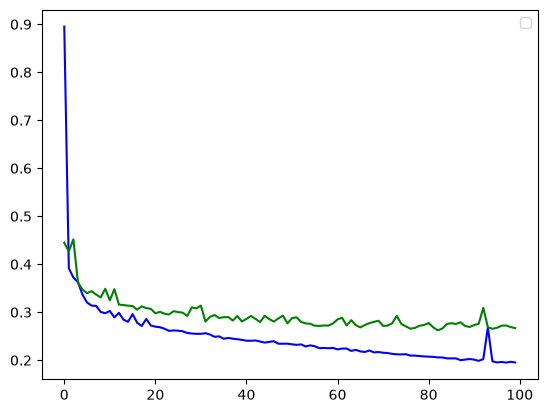

In [180]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], color = 'blue')
plt.plot(history.history['val_loss'], color = 'green')
plt.legend()
plt.show()

In [181]:
from sklearn.metrics import r2_score
import numpy as np

y_pred = model.predict(X_test)
print("r2_score: ", r2_score(y_test, y_pred))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
r2_score:  0.7976538197068952


### After applying Batch Normalization

In [197]:
model2 = Sequential()

In [198]:
model2.add(Dense(90, activation = 'relu',input_dim = 8))
model2.add(BatchNormalization())
model2.add(Dense(90, activation= 'relu'))
model2.add(BatchNormalization())
model2.add(Dense(1, activation = 'linear'))


d:\DeepLearning.py\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [199]:
model2.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 90)             │           810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 90)             │           360 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 90)             │         8,190 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 90)             │           360 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            91 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,811 (38.32 KB)

 Trainable params: 9,451 (36.92 KB)

 Non-trainable params: 360 (1.41 KB)

In [200]:
adam = Adam(learning_rate= 0.01)

In [201]:
model2.compile(loss = 'mse', optimizer= adam, metrics = [R2Score])


In [202]:
history2 = model2.fit(X_train, y_train, epochs = 100, callbacks= callback, validation_split = 0.2)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6260 - r2_score: 0.5293 - val_loss: 0.4943 - val_r2_score: 0.6378
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4164 - r2_score: 0.6869 - val_loss: 0.5318 - val_r2_score: 0.6103
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3855 - r2_score: 0.7101 - val_loss: 0.3939 - val_r2_score: 0.7114
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3853 - r2_score: 0.7103 - val_loss: 0.4424 - val_r2_score: 0.6758
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3755 - r2_score: 0.7177 - val_loss: 0.4029 - val_r2_score: 0.7047
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3699 - r2_score: 0.7219 - val_loss: 0.4032 - val_r2_score: 0.7046
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3601 - r2_score: 0.7292 - val_loss: 0.3668 - val_r2_score: 0.7312
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3596 - r2_score: 0.7296 - val_loss

C:\Users\Dell\AppData\Local\Temp\ipykernel_14424\3017164286.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


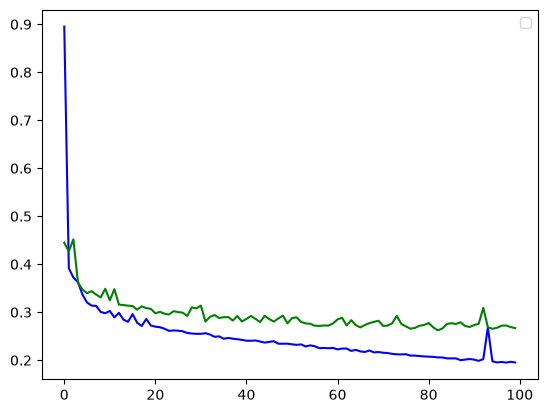

In [203]:
plt.plot(history.history['loss'], color = 'blue')
plt.plot(history.history['val_loss'], color = 'green')
plt.legend()
plt.show()

In [204]:
y_pred2 = model2.predict(X_test)
print('r2_score: ', r2_score(y_test, y_pred))

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
r2_score:  0.7976538197068952


### Conclusion

#### With batch normalization model took less time to train. Without batch norm model took around 6 minutes and with batch norm model took around 3 minutes to train

### 